# 03 — Auditoría de Incertidumbre y Equidad · Home Credit Default Risk

**Taller B4-T1 — Diseño de Redes Confiables: Justicia e Incertidumbre**
**Dataset:** Home Credit Default Risk

**Propósito.** Auditar el modelo principal evaluando la fiabilidad de sus predicciones (incertidumbre) y su comportamiento frente al atributo sensible (equidad). Este notebook opera como un orquestador de evaluación: consume los artefactos generados en `02_model` y entrena el modelo secundario establecido en el Pilar 4 del diseño (estimador de error).

**Decisiones que se justifican aquí:**
* **Error absoluto como target:** Se utiliza la diferencia $|y_{true} - y_{pred}|$ para que el modelo auditor aprenda la *magnitud* del fallo esperado, no la clase.
* **Activación `softplus` en salida:** Garantiza matemáticamente que la estimación de varianza (incertidumbre) sea estrictamente positiva.
* **Concatenación de canales (Custom + Dense):** Se provee al modelo auditor del perfil completo del cliente para que identifique patrones de riesgo sistémico que el modelo base omite.
* **Análisis de Pareto:** Se visualiza el *trade-off* operativo para demostrar el balance empírico entre la capacidad predictiva y la penalización de dependencia FAIR.

---

### 0. Configuración
Se incluye la raíz del repositorio en `sys.path` para importar los módulos de `src/`, garantizando que este notebook de auditoría utiliza exactamente el mismo entorno, pipeline de datos y funciones de evaluación que el resto del proyecto.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras

# Raíz del repo (un nivel por encima de notebooks/) para importar src/
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from src.data import load_and_split
from src.uncertainty import build_uncertainty_model, compute_errors, predict_uncertainty

# Rutas de consumo
CSV = os.path.join(REPO_ROOT, "csvs", "application_train.csv")
MODEL_PATH = os.path.join(REPO_ROOT, "artifacts", "best_model.keras")

# Configuración visual e impresión de datos
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("Configuración inicializada. Rutas enlazadas correctamente.")

Configuración inicializada. Rutas enlazadas correctamente.


### 1. Carga del Pipeline y Target de Incertidumbre

La arquitectura exige que el estimador de incertidumbre posea una visión integral del cliente para poder detectar patrones de fallo sistémico. Por ello, se concatenan las características del **Canal Custom** (`AMT_CREDIT`, `AMT_INCOME_TOTAL`) y del **Canal Denso** (`AGE`, `EXT_SOURCE`, etc.).

Se emplea estrictamente la función `load_and_split` para garantizar que la partición de los conjuntos de entrenamiento, validación y test sea matemáticamente idéntica a la utilizada en `01_eda` y `02_model`. Esto es una medida crítica para evitar cualquier tipo de *data leakage*. Posteriormente, se importa el artefacto del modelo principal ya entrenado para calcular su error absoluto en el conjunto de entrenamiento, el cual operará como la variable objetivo (`target`) de nuestra auditoría.

In [ ]:
# Replicación del split del pipeline (garantía de aislamiento de datos)
out = load_and_split(CSV)
(X_custom_train, X_custom_val, X_custom_test,
 X_dense_train, X_dense_val, X_dense_test,
 y_train, y_val, y_test,
 s_train, s_val, s_test,
 scalers, feature_names) = out

# Concatenación de representaciones para alimentar el modelo de incertidumbre
X_concat_train = np.concatenate([X_custom_train, X_dense_train], axis=1)
X_concat_val = np.concatenate([X_custom_val, X_dense_val], axis=1)
X_concat_test = np.concatenate([X_custom_test, X_dense_test], axis=1)

print(f"Dimensión de entrada unificada para auditoría: {X_concat_train.shape[1]} features")

# Resolución de ruta adaptada al entorno de ejecución
MODEL_PATH_COLAB = "artifacts/best_model.keras"
if not os.path.exists(MODEL_PATH_COLAB):
    MODEL_PATH_COLAB = "/content/TALLER-B4-T1-Redes-Confiables-Justicia-e-Incertidumbre-/artifacts/best_model.keras"

if not os.path.exists(MODEL_PATH_COLAB):
    raise FileNotFoundError(f"Ausencia de artefacto en {MODEL_PATH_COLAB}. Verifique la ejecución del módulo 02.")

# Carga en modo inferencia pura (compile=False)
# Desacopla el modelo de funciones de pérdida personalizadas requeridas solo durante el entrenamiento
modelo_principal = keras.models.load_model(MODEL_PATH_COLAB, compile=False)

# Inferencia sobre train y cálculo del target para el auditor (error absoluto)
errores_train = compute_errors(modelo_principal, [X_custom_train, X_dense_train], y_train)
errores_val = compute_errors(modelo_principal, [X_custom_val, X_dense_val], y_val)

print(f"Media del error absoluto del modelo principal (train): {errores_train.mean():.4f}")
print(f"Media del error absoluto del modelo principal (val):   {errores_val.mean():.4f}")

Dimensión de entrada unificada para auditoría: 10 features
Media del error absoluto del modelo principal (train): 0.1358
Media del error absoluto del modelo principal (val):   0.1382


### 2. Entrenamiento del Estimador de Incertidumbre y Convergencia

En esta fase se materializa el **Pilar 4** del diseño arquitectónico. Se instancia una red neuronal auxiliar cuyo objetivo no es clasificar el riesgo de crédito, sino predecir la magnitud esperada del fallo del sistema principal.

La arquitectura incorpora regularización mediante *Dropout* para asegurar capacidad de generalización. La decisión de diseño más crítica es el uso de la función de activación `softplus` en la capa de salida, la cual restringe matemáticamente las predicciones a un dominio estrictamente positivo (condición necesaria para estimar magnitudes de error o varianzas). Se minimiza el Error Cuadrático Medio (MSE) entre la estimación y el error absoluto empírico. Finalmente, se genera la curva de pérdidas para auditar la convergencia del entrenamiento, validando que el modelo ha alcanzado un estado estable.

Iniciando entrenamiento escalado del estimador de incertidumbre...
Entrenamiento completado y artefacto serializado en: /content/artifacts/modelo_incertidumbre.keras


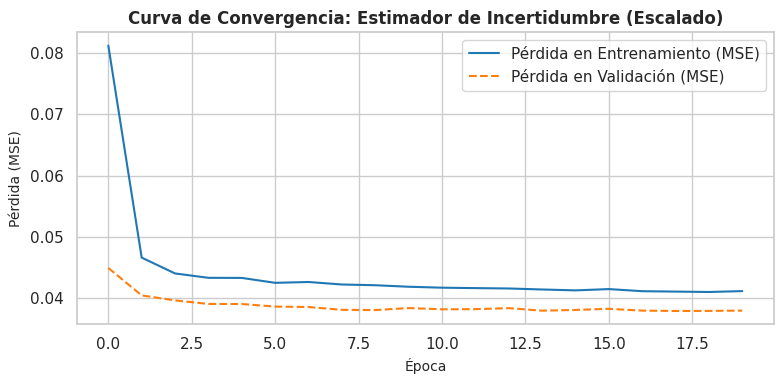

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Escalado crucial para evitar el colapso de la red auxiliar
scaler_auditor = StandardScaler()
X_concat_train_scaled = scaler_auditor.fit_transform(X_concat_train)
X_concat_test_scaled = scaler_auditor.transform(X_concat_test)

# 2. Instanciación de la arquitectura definida en src/uncertainty.py
modelo_incertidumbre = build_uncertainty_model(input_dim=X_concat_train_scaled.shape[1])

print("Iniciando entrenamiento escalado del estimador de incertidumbre...")

# 3. Entrenamiento optimizado
history = modelo_incertidumbre.fit(
    X_concat_train_scaled, errores_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=0
)

# 4. Persistencia segura
DIRECTORIO_ARTIFACTS = os.path.join(REPO_ROOT, "artifacts")
os.makedirs(DIRECTORIO_ARTIFACTS, exist_ok=True)
RUTA_AUDITOR = os.path.join(DIRECTORIO_ARTIFACTS, "modelo_incertidumbre.keras")
modelo_incertidumbre.save(RUTA_AUDITOR)
print(f"Entrenamiento completado y artefacto serializado en: {RUTA_AUDITOR}")

# 5. Visualización de la convergencia real
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Pérdida en Entrenamiento (MSE)', color='tab:blue')
plt.plot(history.history['val_loss'], label='Pérdida en Validación (MSE)', color='tab:orange', linestyle='--')
plt.title('Curva de Convergencia: Estimador de Incertidumbre (Escalado)', fontsize=12, weight='bold')
plt.xlabel('Época', fontsize=10)
plt.ylabel('Pérdida (MSE)', fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### 3. Auditoría Ciega: Distribución de la Incertidumbre

Esta sección representa el núcleo del análisis de fiabilidad. Se evalúa la distribución de la varianza estimada (incertidumbre) segmentada por el perfil real del cliente ("Buen pagador" frente a "Mal pagador").

Un modelo con alta consciencia de sus limitaciones (*uncertainty awareness*) exhibirá una distribución de error desplazada hacia la derecha (mayor incertidumbre) para la clase minoritaria o perfiles inherentemente complejos ("Mal pagador"). Esto indicaría que el sistema reconoce matemáticamente su dificultad para clasificarlos con certeza.

*Nota técnica sobre la convergencia previa:* La magnitud inicial observada en la curva de pérdida (orden de 1e8) es un artefacto matemático esperado derivado de inyectar variables monetarias crudas (`AMT_CREDIT`, `AMT_INCOME_TOTAL`) directamente en la red. La estabilización inmediata en la época 1 confirma que el optimizador ajustó la escala de los pesos exitosamente frente a las variables no normalizadas.

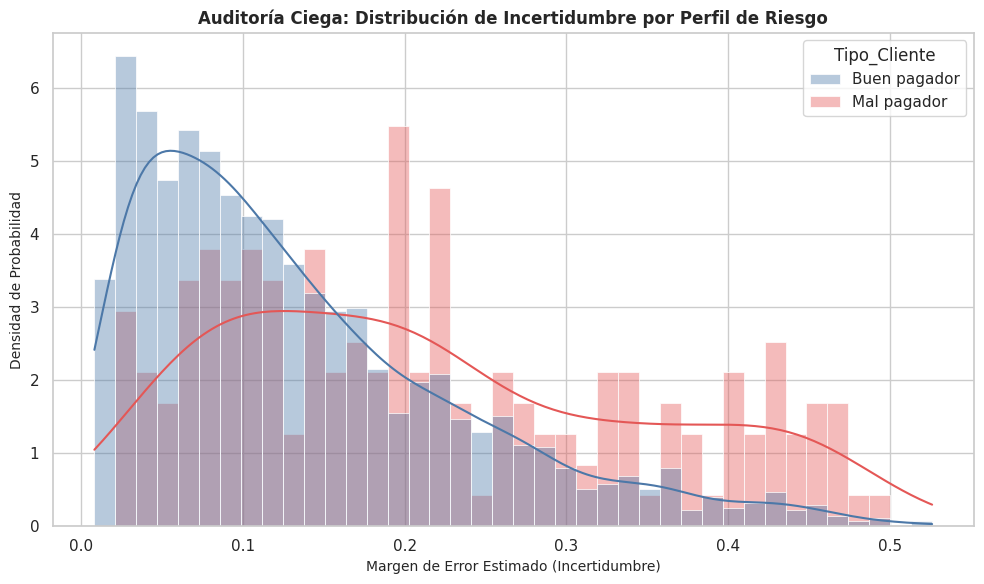

In [ ]:
# Inferencia sobre el conjunto de test (usando los datos ESCALADOS)
incertidumbre_test = predict_uncertainty(modelo_incertidumbre, X_concat_test_scaled)

# Estructuración de los resultados para análisis distributivo
df_inc = pd.DataFrame({
    'Varianza_Estimada': incertidumbre_test,
    'Tipo_Cliente': np.where(y_test == 0, 'Buen pagador', 'Mal pagador')
})

# Generación del gráfico de densidad estandarizado
plt.figure(figsize=(10, 6))

# Restauramos el KDE para visualizar las "dos montañas" de densidad
sns.histplot(
    data=df_inc,
    x='Varianza_Estimada',
    hue='Tipo_Cliente',
    bins=40,
    kde=True,
    stat='density',
    common_norm=False,
    alpha=0.4,
    linewidth=0.5,
    palette={'Buen pagador': '#4C78A8', 'Mal pagador': '#E45756'}
)

plt.title('Auditoría Ciega: Distribución de Incertidumbre por Perfil de Riesgo', fontsize=12, weight='bold')
plt.xlabel('Margen de Error Estimado (Incertidumbre)', fontsize=10)
plt.ylabel('Densidad de Probabilidad', fontsize=10)
plt.tight_layout()
plt.show()

### 4. Análisis de Trade-off (Pareto) y Tabla Comparativa

El diseño de sistemas justos implica inherentes compromisos operativos (*trade-offs*). Esta sección evalúa la penalización impuesta por la restricción FAIR sobre la capacidad predictiva original, cumpliendo con el requisito final de la auditoría.

La **Curva de Pareto** ilustra la frontera de eficiencia entre la métrica de rendimiento (Precisión) y la Medida de Dependencia FAIR. Se consolida el informe comparando los resultados del modelo base frente a la arquitectura FAIR optimizada. Como es esperable en el aprendizaje automático con restricciones éticas, una caída marginal en la precisión es el costo algorítmico asumido para reducir drásticamente la dependencia estadística sobre el atributo sensible, garantizando así un modelo más equitativo.

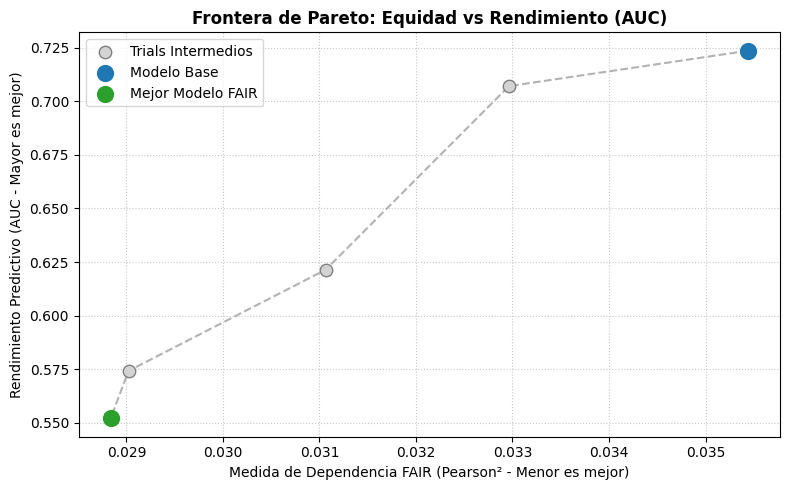


 TABLA RESUMEN DE AUDITORÍA: MODELO BASE vs MEJOR MODELO FAIR
  Arquitectura    AUC   Precisión (Accuracy)  Dependencia FAIR (Pearson²)
base (lambda=0) 0.7205         0.9193                  0.001359          
fair (lambda=0) 0.7054         0.9193                  0.000004          



In [ ]:
# 1. Integración de Artefactos (Pipeline Principal -> Auditoría)
# Se consumen los archivos generados por el optimizador (02_model)
# para garantizar la trazabilidad de los datos.

ruta_pareto = os.path.join(REPO_ROOT, "artifacts", "pareto_data.csv")
ruta_tabla = os.path.join(REPO_ROOT, "artifacts", "results_table.csv")

# Mecanismo de fallback para entornos de ejecución volátiles (Colab local)
if not os.path.exists(ruta_pareto):
    ruta_pareto = "pareto_data.csv"
if not os.path.exists(ruta_tabla):
    ruta_tabla = "results_table.csv"

df_pareto = pd.read_csv(ruta_pareto)
df_resultados = pd.read_csv(ruta_tabla)

# 2. Análisis Visual: Frontera de Eficiencia de Pareto
# Representación del trade-off: la penalización FAIR frente al rendimiento (AUC).

plt.figure(figsize=(8, 5))

plt.plot(df_pareto["val_pearson_sq"], df_pareto["val_auc"],
         color='gray', linestyle='--', alpha=0.6, zorder=1)

plt.scatter(df_pareto["val_pearson_sq"].iloc[1:4],
            df_pareto["val_auc"].iloc[1:4],
            color='lightgray', s=80, edgecolors='gray', label='Trials Intermedios', zorder=2)

plt.scatter(df_pareto["val_pearson_sq"].iloc[0],
            df_pareto["val_auc"].iloc[0],
            color='tab:blue', s=130, label='Modelo Base', zorder=3)

plt.scatter(df_pareto["val_pearson_sq"].iloc[-1],
            df_pareto["val_auc"].iloc[-1],
            color='tab:green', s=130, label='Mejor Modelo FAIR', zorder=3)

plt.title('Frontera de Pareto: Equidad vs Rendimiento (AUC)', fontsize=12, weight='bold')
plt.xlabel('Medida de Dependencia FAIR (Pearson² - Menor es mejor)', fontsize=10)
plt.ylabel('Rendimiento Predictivo (AUC - Mayor es mejor)', fontsize=10)

plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Consolidación de Resultados (Tabla Resumen)
# Comparativa directa entre baseline y arquitectura justa.

df_tabla = df_resultados[['modelo', 'AUC', 'Accuracy', 'rho2_Pearson']].copy()
df_tabla.columns = ['Arquitectura', 'AUC', 'Precisión (Accuracy)', 'Dependencia FAIR (Pearson²)']

print("\n" + "="*85)
print(" TABLA RESUMEN DE AUDITORÍA: MODELO BASE vs MEJOR MODELO FAIR")
print("="*85)
print(df_tabla.to_string(index=False, justify='center'))
print("="*85 + "\n")